In [41]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier


# Plotly
import plotly.io as pio
pio.renderers.default = "iframe"


print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

TARGET = "Will_Buy_EV"
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_TRIALS = 50
KAGGLE_DATASET_URL = "/kaggle/input/competitions/playground-series-s6e9/"

DATA_PATHS = [
    Path(KAGGLE_DATASET_URL),
    Path("/kaggle/input"),
    Path.cwd(),
    Path.cwd() / "input",
    Path.cwd().parent,
    Path.cwd().parent / "input",
]

In [43]:
# ============================================================
# 3. FIND DATA DIRECTORY
# ============================================================

def find_data_dir(paths):
    for path in paths:
        if (
            (path / "train.csv").exists()
            and (path / "test.csv").exists()
            and (path / "sample_submission.csv").exists()
        ):
            return path

    raise FileNotFoundError(
        "Could not find train.csv, test.csv and sample_submission.csv."
    )


data_dir = find_data_dir(DATA_PATHS)

print(f"Data directory: {data_dir}")

Data directory: c:\Users\User\Desktop\New folder\local-git\Predicting-Electric-Vehicle-Purchases\input


In [44]:
# ============================================================
# 4. LOAD DATA
# ============================================================

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

display(train.head())

Train shape: (668665, 15)
Test shape:  (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [45]:
# ============================================================
# 5. BASIC DATA INFORMATION
# ============================================================

print("\nTrain information:")
train.info()

print("\nTest information:")
test.info()

print("\nMissing values:")
display(
    train.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

print("\nTarget distribution:")
display(train[TARGET].value_counts(dropna=False))


Train information:
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str

,Missing
id,0
Age,0
Annual_Income_USD,0
Daily_Commute_km,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0



Target distribution:


Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

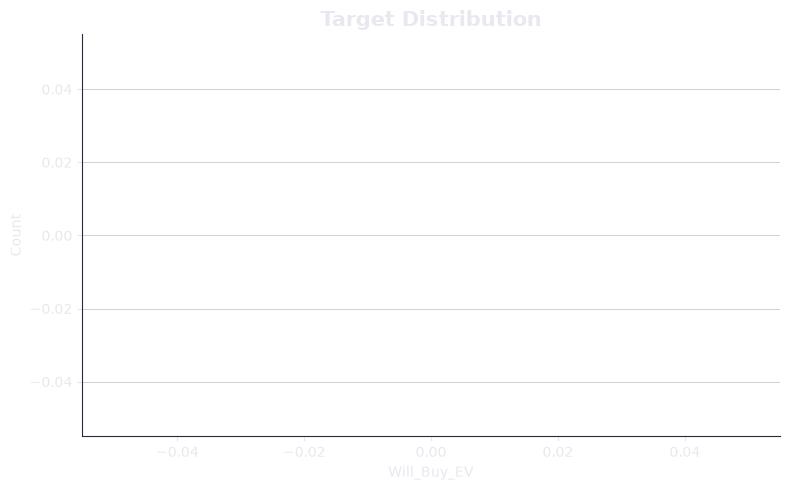

In [46]:
# ============================================================
# 6. TARGET ANALYSIS
# ============================================================

target = pd.to_numeric(
    train[TARGET],
    errors="coerce"
).dropna()

counts = target.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    counts.index,
    counts.values,
    color="#6C63FF",
    alpha=0.85,
    edgecolor="black"
)

ax.set_title(
    "Target Distribution",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(TARGET)
ax.set_ylabel("Count")

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# Normality test is only useful for continuous variables.
# For a binary target, it is not meaningful.
if target.nunique() > 2 and len(target) >= 3:
    statistic, p_value = stats.shapiro(target)

    print(
        f"Shapiro-Wilk: statistic={statistic:.4f}, "
        f"p-value={p_value:.4e}"
    )

In [47]:
# ============================================================
# 7. DATASET SUMMARY
# ============================================================

def data_summary(df):
    summary = pd.DataFrame({
        "Unique": df.nunique(),
        "Missing": df.isnull().sum(),
        "Missing %": df.isnull().mean(),
        "Top Value": [
            df[col].mode().iloc[0]
            if not df[col].dropna().empty
            else np.nan
            for col in df.columns
        ],
        "Top Value %": [
            df[col].value_counts(normalize=True).iloc[0]
            if not df[col].dropna().empty
            else 0
            for col in df.columns
        ]
    })

    return summary.sort_values(
        "Missing",
        ascending=False
    )


display(data_summary(train))

,Unique,Missing,Missing %,Top Value,Top Value %
id,668665,0,0.0,0,0.000001
Age,45,0,0.0,36,0.026647
Annual_Income_USD,13214,0,0.0,30000.0,0.092131
Daily_Commute_km,805,0,0.0,5.0,0.215773
Number_of_Cars_Owned,4,0,0.0,2,0.446093
Charging_Stations_Near_Home,15,0,0.0,2,0.151865
Charging_Stations_Near_Work,20,0,0.0,3,0.119251
Environmental_Concern_Level,5,0,0.0,1.0,0.220553
Gender,3,0,0.0,Male,0.550282
City_Type,3,0,0.0,Urban,0.432661


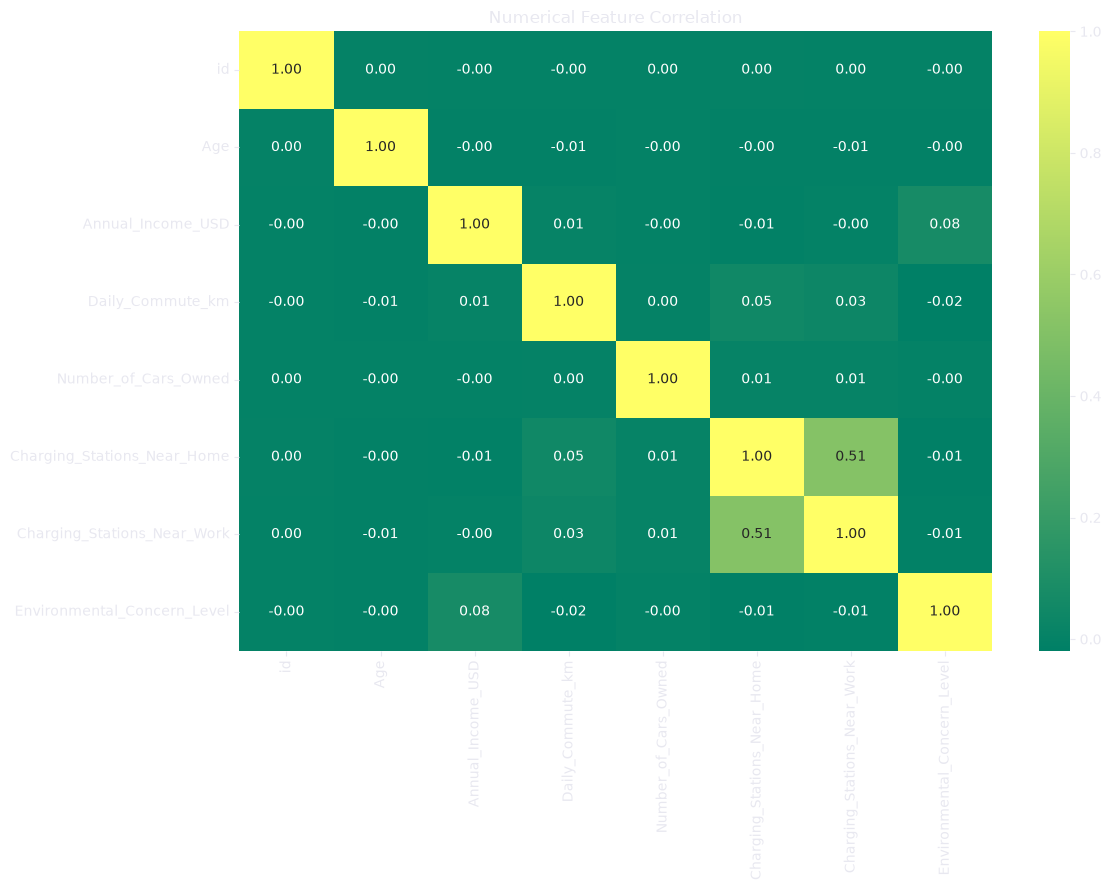

In [48]:
# ============================================================
# 8. NUMERICAL CORRELATION
# ============================================================

numeric_train = train.select_dtypes(
    include=np.number
)

if numeric_train.shape[1] > 1:

    plt.figure(figsize=(12, 9))

    sns.heatmap(
        numeric_train.corr(),
        cmap="summer",
        annot=True,
        fmt=".2f"
    )

    plt.title("Numerical Feature Correlation")

    plt.tight_layout()
    plt.show()

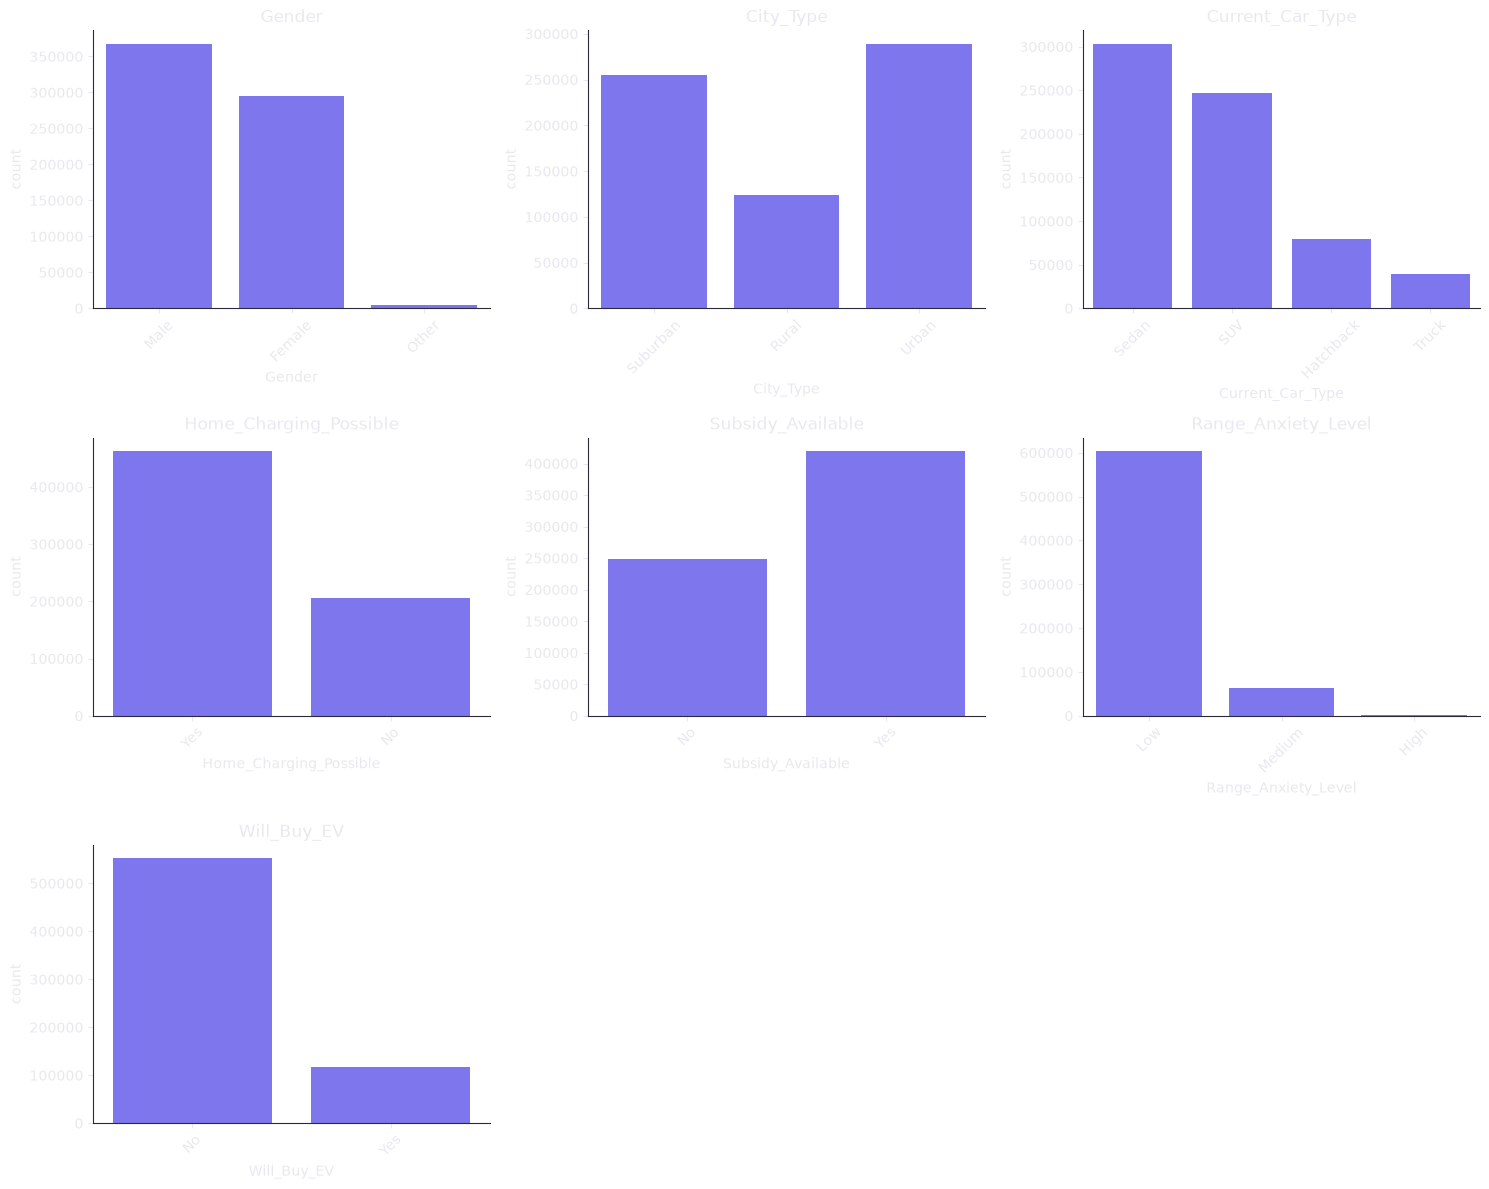

In [49]:
# ============================================================
# 9. CATEGORICAL FEATURE DISTRIBUTIONS
# ============================================================

categorical_columns = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

if categorical_columns:

    n_columns = 3
    n_rows = int(
        np.ceil(len(categorical_columns) / n_columns)
    )

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(15, 4 * n_rows)
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, column in zip(axes, categorical_columns):

        sns.countplot(
            data=train,
            x=column,
            ax=ax,
            color="#6C63FF"
        )

        ax.set_title(column)
        ax.tick_params(axis="x", rotation=45)

    # Hide unused axes
    for ax in axes[len(categorical_columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [50]:
# ============================================================
# 10. SEPARATE FEATURES AND TARGET
# ============================================================

X = train.drop(columns=TARGET).copy()
y = train[TARGET].copy()

X_kaggle_test = test.copy()


# ============================================================
# 11. IDENTIFY COLUMN TYPES
# ============================================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)



Categorical columns:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

Numerical columns:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']


In [51]:
# ============================================================
# 12. HANDLE MISSING VALUES
# ============================================================

# Categorical missing values
for column in categorical_cols:

    X[column] = X[column].fillna("None")
    X_kaggle_test[column] = X_kaggle_test[column].fillna("None")


# Numerical missing values
# Median is more robust than mean when outliers exist.
for column in numeric_cols:

    fill_value = X[column].median()

    X[column] = X[column].fillna(fill_value)
    X_kaggle_test[column] = X_kaggle_test[column].fillna(fill_value)

In [52]:
# ============================================================
# 13. ENCODE CATEGORICAL FEATURES
# ============================================================

if categorical_cols:

    feature_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X[categorical_cols] = feature_encoder.fit_transform(
        X[categorical_cols].astype(str)
    )

    X_kaggle_test[categorical_cols] = feature_encoder.transform(
        X_kaggle_test[categorical_cols].astype(str)
    )


In [53]:
# ============================================================
# 14. ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print("\nTarget classes:")
print(target_encoder.classes_)

print("\nEncoded target values:")
print(np.unique(y))


Target classes:
['No' 'Yes']

Encoded target values:
[0 1]


In [54]:
# ============================================================
# 15. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_valid.shape)


Training shape: (534932, 14)
Validation shape: (133733, 14)


In [ ]:
# ============================================================
# 16. OPTUNA OBJECTIVE
# ============================================================

def objective(trial):

    params = {
        "n_estimators"      : trial.suggest_int("n_estimators"  , 100 , 1000),
        "max_depth"         : trial.suggest_int("max_depth"     , 2   , 12),

        "learning_rate"     : trial.suggest_float("learning_rate"   , 0.01, 0.2,log=True),
        "subsample"         : trial.suggest_float("subsample"       , 0.6 , 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.6 , 1.0),

        "min_child_weight"  : trial.suggest_int("min_child_weight",1,10),

        "gamma"             : trial.suggest_float("gamma"     , 0.0  ,5.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha" , 1e-8 ,10.0,log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-8 ,10.0,log=True)
    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    predictions = model.predict(X_valid)

    return accuracy_score(y_valid,predictions)

In [56]:
# ============================================================
# 17. OPTUNA HYPERPARAMETER OPTIMIZATION
# ============================================================

study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_EV"
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)


print("\n" + "=" * 60)
print("OPTUNA RESULTS")
print("=" * 60)

print(
    f"Best validation accuracy: "
    f"{study.best_value:.4f}"
)

print("\nBest parameters:")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

[I 2026-09-02 05:54:15,733] A new study created in memory with name: XGBoost_EV


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-02 05:54:40,897] Trial 0 finished with value: 0.896570031331085 and parameters: {'n_estimators': 373, 'max_depth': 2, 'learning_rate': 0.03763615097781359, 'subsample': 0.6642092121597103, 'colsample_bytree': 0.6158011221433841, 'min_child_weight': 7, 'gamma': 2.636660056578684, 'reg_alpha': 3.7798513710497157e-06, 'reg_lambda': 3.690711994650206e-08}. Best is trial 0 with value: 0.896570031331085.
[I 2026-09-02 05:55:07,914] Trial 1 finished with value: 0.8980281605886355 and parameters: {'n_estimators': 265, 'max_depth': 12, 'learning_rate': 0.0724492523756963, 'subsample': 0.6758092250865463, 'colsample_bytree': 0.6258245052611758, 'min_child_weight': 8, 'gamma': 3.1936670279384973, 'reg_alpha': 0.24817210544638657, 'reg_lambda': 1.299736362317671}. Best is trial 1 with value: 0.8980281605886355.
[I 2026-09-02 05:56:28,935] Trial 2 finished with value: 0.8970485968309991 and parameters: {'n_estimators': 710, 'max_depth': 11, 'learning_rate': 0.05551098676572935, 'subsampl

In [57]:
# ============================================================
# 18. VALIDATION MODEL
# ============================================================

validation_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

validation_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

validation_predictions = validation_model.predict(X_valid)

In [58]:
# ============================================================
# 19. VALIDATION REPORT
# ============================================================

validation_accuracy = accuracy_score(y_valid, validation_predictions)

print("\nValidation Accuracy:")
print(f"{validation_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        validation_predictions,
        target_names=target_encoder.classes_.astype(str)
    )
)



Validation Accuracy:
0.8982

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.95      0.94    110377
         Yes       0.72      0.67      0.70     23356

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



In [59]:
# ============================================================
# 20. TRAIN FINAL MODEL ON ALL TRAINING DATA
# ============================================================

final_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7546203248907811
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


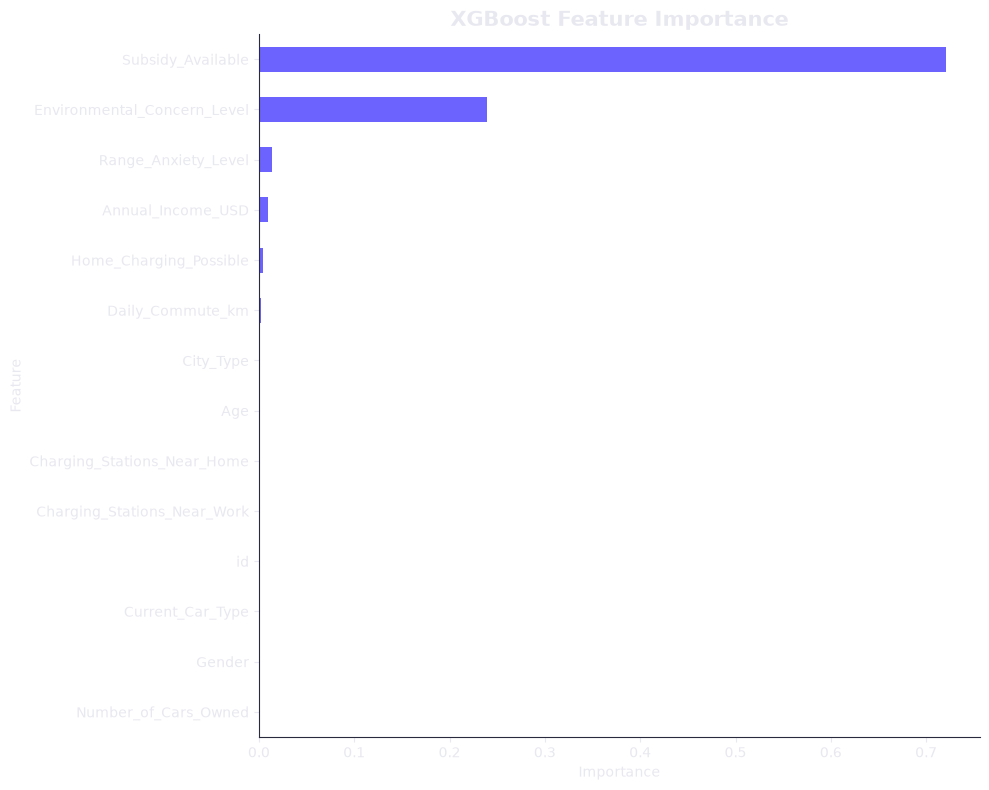

In [60]:
# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

feature_importance = (
    pd.Series(
        final_model.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))

feature_importance.plot(
    kind="barh",
    color="#6C63FF"
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# 22. PREDICT KAGGLE TEST DATA
# ============================================================

test_predictions_encoded = final_model.predict(X_kaggle_test)

test_predictions = target_encoder.inverse_transform(test_predictions_encoded)

# Get probability for the positive class (Will_Buy_EV = 1)
test_predictions = final_model.predict_proba(X_kaggle_test)[:, 1]

print("\nTest prediction preview:")
print(test_predictions[:5])


Test prediction preview:
[0.01027457 0.01867312 0.00671895 0.00380844 0.01763373]


In [67]:
# ============================================================
# 23. CREATE SUBMISSION
# ============================================================

submission = sample_submission.copy()

if len(submission) != len(test_predictions):
    raise ValueError("Submission row count does not match test row count.")

# submission[TARGET] = test_predictions
submission[TARGET] = test_predictions.astype(float)

In [68]:
# ============================================================
# 24. VERIFY SUBMISSION
# ============================================================

print("\nSubmission preview:")
display(submission.head())


print("\nSubmission shape:")
print(submission.shape)

print("\nSubmission target distribution:")
print(submission[TARGET].value_counts())

print("\nMissing values in submission:")
print(submission.isnull().sum())


Submission preview:


,id,Will_Buy_EV
0,668665,0.010275
1,668666,0.018673
2,668667,0.006719
3,668668,0.003808
4,668669,0.017634



Submission shape:
(286571, 2)

Submission target distribution:
Will_Buy_EV
0.012632    3
0.010743    3
0.002772    3
0.568462    3
0.016776    3
           ..
0.000378    1
0.283364    1
0.002977    1
0.000694    1
0.000248    1
Name: count, Length: 284806, dtype: int64

Missing values in submission:
id             0
Will_Buy_EV    0
dtype: int64


In [70]:
# ============================================================
# 25. SAVE SUBMISSION
# ============================================================

submission_path = Path("submission.parquet")

submission.to_parquet(submission_path,index=False)

print("Submission saved successfully")

Submission saved successfully
